In [2]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

setting configaration

In [29]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x :f"{x:.3f}")
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'axes.titlesize':10,
    'axes.labelsize':9,
    'xtick.labelsize':8,
    'ytick.labelsize':8
})
RANDOM_STATE=42
CSV_FILE="insurance.csv"
target_cols="=charges"


In [5]:
df=pd.read_csv(CSV_FILE)

In [6]:
df.shape

(1338, 7)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [8]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
for col in df.columns:
    print(df[col].value_counts().head())

age
18    69
19    68
46    29
52    29
48    29
Name: count, dtype: int64
sex
male      676
female    662
Name: count, dtype: int64
bmi
32.300    13
28.310     9
28.880     8
34.100     8
30.800     8
Name: count, dtype: int64
children
0    574
1    324
2    240
3    157
4     25
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
charges
1639.563     2
16884.924    1
1725.552     1
4449.462     1
21984.471    1
Name: count, dtype: int64


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [18]:
nums_cols=df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols=df.select_dtypes(include=["string"]).columns.tolist()

In [20]:
cat_cols

['sex', 'smoker', 'region']

In [24]:
duplicate_mask=df.duplicated()
duplicate_mask.sum()
df=df.drop_duplicates()

In [25]:
df[nums_cols].describe()

,age,bmi,children,charges
count,1337.000,1337.000,1337.000,1337.000
mean,39.222,30.663,1.096,13279.121
std,14.044,6.100,1.206,12110.360
min,18.000,15.960,0.000,1121.874
25%,27.000,26.290,0.000,4746.344
50%,39.000,30.400,1.000,9386.161
75%,51.000,34.700,2.000,16657.717
max,64.000,53.130,5.000,63770.428


In [26]:
 for col in cat_cols:
    print(df[col].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


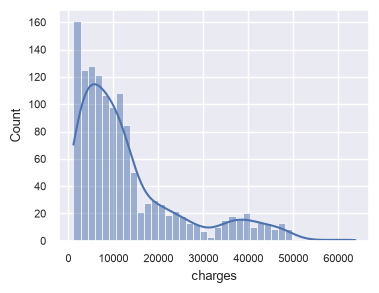

In [31]:
plt.figure(figsize=(4,3))
sns.histplot(df['charges'],bins=40,kde=True)
plt.show()

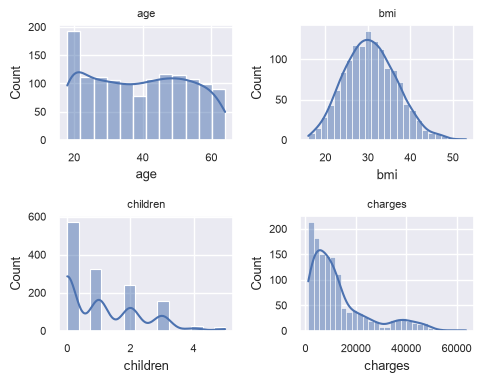

In [38]:
fig,axes=plt.subplots(2,2,figsize=(5,4))
axes=axes.flatten()

for i,col in enumerate(nums_cols):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)
plt.tight_layout()
plt.show()

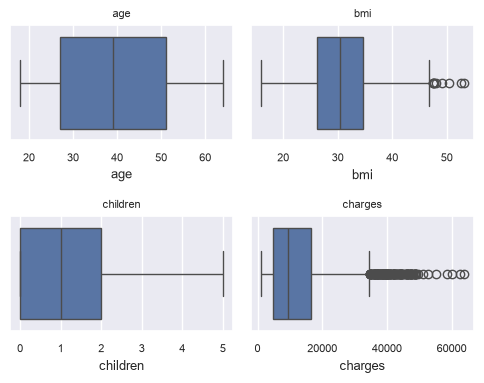

In [41]:
fig,axes=plt.subplots(2,2,figsize=(5,4))
axes=axes.flatten()

for i,col in enumerate(nums_cols):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col,fontsize=8)
plt.tight_layout()
plt.show()

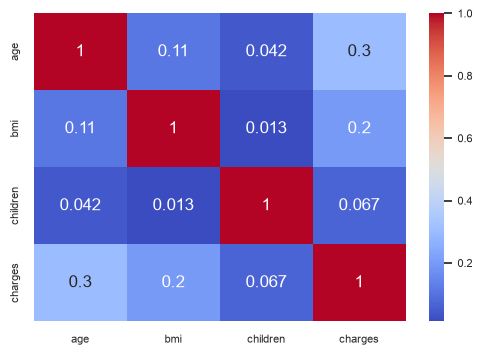

In [48]:


plt.figure(figsize=(6,4))
sns.heatmap(df[nums_cols].corr(),annot=True,cmap="coolwarm")
    # axes[i].set_title(col,fontsize=8)
# plt.tight_layout()
plt.show()

In [51]:
corr_target=df[nums_cols].corr()['charges'].sort_values(ascending=True)
corr_target

children   0.067
bmi        0.198
age        0.298
charges    1.000
Name: charges, dtype: float64

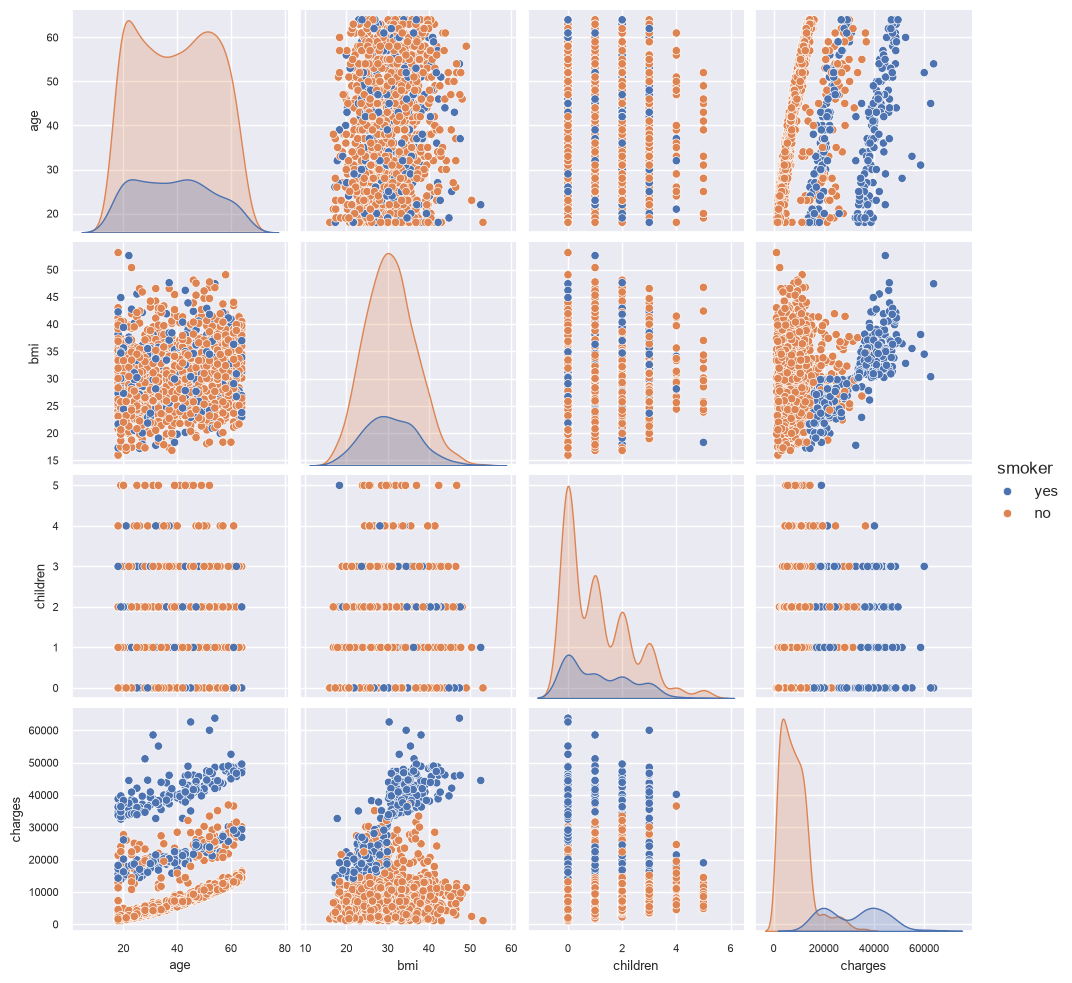

In [53]:
sns.pairplot(df,hue="smoker")
plt.show()

In [54]:
x=df.drop(columns=['charges'])
y=df['charges']
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [62]:
nums_cols_pipe=X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_pipe=X_train.select_dtypes(include=["string"]).columns.tolist()


In [63]:
nums_cols_pipe
cat_cols_pipe

['sex', 'smoker', 'region']

In [68]:
numeric_cols_pipe=Pipeline(
    steps=[
        ("scaler",StandardScaler())
    ]
)

categorical_cols_pipe=Pipeline(
    steps=[
        ("ohe",OneHotEncoder(drop="first",handle_unknown="ignore"))
    ]
)

preprocess=ColumnTransformer(
    transformers=[
        ("nums",numeric_cols_pipe,nums_cols_pipe),
        ("cat",categorical_cols_pipe,cat_cols_pipe),
        
        
    ]
)

In [ ]:
baseline_pipe=Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",LinearRegression())
    ]
)

In [70]:
baseline_pipe.fit(X_train,y_train)  

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the o

In [71]:
y_train_pred=baseline_pipe.predict(X_train)
y_test_pred=baseline_pipe.predict(X_test)

y_train_mse=root_mean_squared_error(y_train,y_train_pred)
y_train_mae=mean_absolute_error(y_train,y_train_pred)
y_train_r2=r2_score(y_train,y_train_pred)


print(" Root Mean squared Error :" ,y_train_mse)
print(" Mean Absolute Error :",y_train_mae )
print(" r2 Score :",y_train_r2 )




 Root Mean squared Error : 6081.106881541277
 Mean Absolute Error : 4181.9015377751475
 r2 Score : 0.7299057809339075


In [72]:
y_test_mse=root_mean_squared_error(y_test,y_test_pred)
y_test_mae=mean_absolute_error(y_test,y_test_pred)
y_test_r2=r2_score(y_test,y_test_pred)


print(" Root Mean squared Error :" ,y_test_mse)
print(" Mean Absolute Error :",y_test_mae )
print(" r2 Score :",y_test_r2 )



 Root Mean squared Error : 5956.342894363587
 Mean Absolute Error : 4177.045561036326
 r2 Score : 0.8069287081198012


In [74]:
model_selection={
    'LinearRegression':LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(random_state=42,max_iter=10000),
    "DecisionTree":DecisionTreeRegressor(random_state=42),
    "RandomForest":RandomForestRegressor(random_state=42),
    "XGBoost":XGBRegressor()
}

In [75]:
k=5
cv=KFold(n_splits=5,shuffle=True,random_state=42)

In [76]:
scoring={
    "mae":"neg_mean_absolute_error",
    'rmse':"neg_root_mean_squared_error",
    "r2_score":"r2"
}

In [80]:
rows=[]
for name,model in model_selection.items():
    pipe=Pipeline(
        steps=[
            ("preprocess",preprocess),
            ('model',model)
        ]
    )
    
    scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
    rows.append({
        'model':name,
        "cv_mae":-scores['test_mae'].mean(),
        "cv_rmse":-scores['test_rmse'].mean(),
        "cv_r2":-scores['test_r2_score'].mean()
        
        
    })
    
    
cv_results=pd.DataFrame(rows).sort_values("cv_mae")
print("--------CV mModel comparison___________")
    
    

--------CV mModel comparison___________


In [82]:
cv_results

,model,cv_mae,cv_rmse,cv_r2
4,RandomForest,2788.589,4959.888,-0.817
5,XGBoost,3094.682,5370.251,-0.785
3,DecisionTree,3367.377,6872.197,-0.650
2,Lasso,4221.793,6123.431,-0.723
0,LinearRegression,4221.963,6123.651,-0.723
1,Ridge,4232.149,6123.907,-0.723


In [83]:
best_rows=cv_results.sort_values('cv_mae').iloc[0]
best_model_name=best_rows['model']
best_mae=best_rows['cv_mae']


print("Best model based on result")
print("model :",best_model_name)
print("cv mae:",best_mae)

Best model based on result
model : RandomForest
cv mae: 2788.589166099407


In [93]:
hyper_pipe=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ("model",RandomForestRegressor(
            n_jobs=-1,
            random_state=42,
            verbose=True
            
            
        ))
    ]
)

In [94]:
param_grid={
    'model__n_estimators':[200,300,600,900],
    "model__max_depth":[None,8,15,25],
    
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4],
    
    'model__max_features':['sqrt','log2',0.6,0.8],
    "model__bootstrap":[True]
}

In [95]:
grid=GridSearchCV(
    estimator=hyper_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
    
)

In [96]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    0.6s finished


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbose=True))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__bootstrap': [True], 'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` par

In [99]:
print("best cv mae:",-grid.best_score_)
print("best params:",grid.best_params_)


best cv mae: 2554.851472704811
best params: {'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 0.8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 300}


Retrain our model

In [122]:
retrain=Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",RandomForestRegressor(
            bootstrap=True,
            max_depth=8,
            max_features=0.8,
            min_samples_leaf=4,
            min_samples_split=2,
            n_estimators=300,
            random_state=42,
            verbose=0
            
            
            
        ))
    ]
)

In [123]:
retrain.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the o

In [102]:
y_train_pred=retrain.predict(X_train)
y_test_pred=retrain.predict(X_test)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.0s finished


In [103]:
y_train_mse=root_mean_squared_error(y_train,y_train_pred)
y_train_mae=mean_absolute_error(y_train,y_train_pred)
y_train_r2=r2_score(y_train,y_train_pred)


print(" Root Mean squared Error :" ,y_train_mse)
print(" Mean Absolute Error :",y_train_mae )
print(" r2 Score :",y_train_r2 )



 Root Mean squared Error : 3727.5526201084267
 Mean Absolute Error : 2031.21297828872
 r2 Score : 0.8985159988808483


In [104]:
y_test_mse=root_mean_squared_error(y_test,y_test_pred)
y_test_mae=mean_absolute_error(y_test,y_test_pred)
y_test_r2=r2_score(y_test,y_test_pred)


print(" Root Mean squared Error :" ,y_test_mse)
print(" Mean Absolute Error :",y_test_mae )
print(" r2 Score :",y_test_r2 )



 Root Mean squared Error : 4306.436837351445
 Mean Absolute Error : 2410.9735621525447
 r2 Score : 0.8990759933236837


In [119]:
rf_best_log=TransformedTargetRegressor(
    regressor=Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",RandomForestRegressor(
            bootstrap=True,
            max_depth=8,
            max_features=0.8,
            min_samples_leaf=4,
            min_samples_split=2,
            n_estimators=300,
            random_state=42,
            verbose=0 
        ))
    ]
),
    func=np.log1p,
    inverse_func=np.expm1
)

In [120]:
rf_best_log.fit(X_train,y_train)


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,6
regressor_ regressor_: objectFitted regressor.,Pipeline,Pipeline(step...m_state=42))])
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,FunctionTransformer,FunctionTrans...validate=True)
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"


In [121]:
y_train_pred_log=rf_best_log.predict(X_train)
y_test_pred_log=rf_best_log.predict(X_test)

In [109]:
y_train_mse_log=root_mean_squared_error(y_train,y_train_pred_log)
y_train_mae_log=mean_absolute_error(y_train,y_train_pred_log)
y_train_r2_log=r2_score(y_train,y_train_pred_log)


print(" Root Mean squared Error :" ,y_train_mse_log)
print(" Mean Absolute Error :",y_train_mae_log )
print(" r2 Score :",y_train_r2_log )



 Root Mean squared Error : 3988.7835916008617
 Mean Absolute Error : 1713.732825084128
 r2 Score : 0.8837933544543476


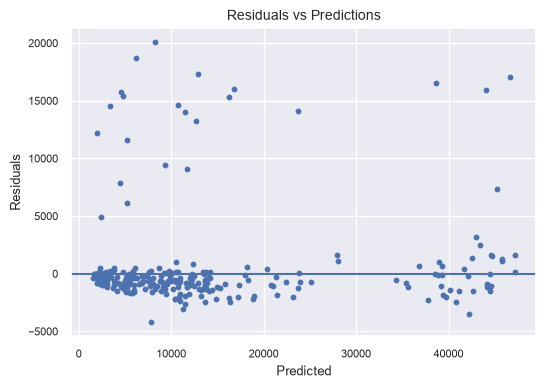

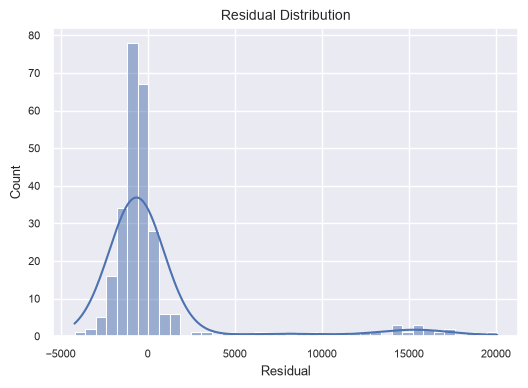

In [110]:
# residual plot
residuals = y_test - y_test_pred_log

plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred_log, residuals, s=10)
plt.axhline(8)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt. show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt. show()


In [130]:
def insurance_predictor(
    age:float,
    sex:str,
    bmi:float,
    children:int,
    smoker:str,
    region:str,
    
):
    new_rows=pd.DataFrame([{
        "age":age,
        "sex":sex,
        "bmi":bmi,
        "children":children,
        "smoker":smoker,
        "region":region
    }])
    
    insurance=retrain.predict(new_rows)[0]
    return round(insurance,4)
    
    
    
    # return float(model.predict(new_rows)[0])

In [131]:
pred = insurance_predictor(

age=35,
sex="male",
bmi=29.5,
children=2,
smoker="no",
region="southeast"
)


In [132]:
print(pred)

6610.0357


In [134]:
import pickle
with open("model.pkl",'wb') as file:
    pickle.dump(model,file)
    
    
    
